# XGBoost Daily — v1

Daily-resolution version of xgboost_lasso_v3.
Hourly data is aggregated to daily before modelling.

## Aggregation rules
| Type | Columns | Method |
|---|---|---|
| Price | all el_price nodes | mean |
| Generation | Coal, Diesel, Ele, Gas, Geo, Hydro, Solar, Wind, Wood | sum (MW×24h ≈ MWh) |
| Demand | demand_GWh_* | sum (total daily demand) |
| Flow | avg_flow_MW | mean |
| Flow | peak_flow_MW | max (true daily peak) |
| Flow | Direction | mean |
| Outages | outage_*_MW | mean (capacity rate, not accumulation) |
| Weather | wind, temp, solar, sunshine | mean |
| Hydro | lake_level, active_storage | mean (slow-moving) |
| Holiday | holiday | max (1 if any hour is holiday) |

## Key differences from v3 (hourly)
| | v3 hourly | daily |
|---|---|---|
| Resolution | 1h | 1 day |
| Lags | 24h, 168h, 8760h | 1d, 7d, 365d |
| Rolling windows | 24h, 168h, 8760h | 7d, 30d, 365d |
| Time features | hour+dow+month | dow+month (no hour) |
| CV test window | 720h (~1 month) | 30 days (~1 month) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

In [2]:
df_raw = pd.read_csv('../../Data_Processing/preprocessed_data.csv')
df_raw["datetime_utc12"] = pd.to_datetime(df_raw["datetime_utc12"])
df_raw = df_raw.sort_values("datetime_utc12").reset_index(drop=True)
df_raw = df_raw.ffill()

target_col = "el_price_dol_MWh_OTA2201"
print("Raw hourly shape:", df_raw.shape)

Raw hourly shape: (52585, 81)


In [3]:
# ── Aggregate hourly → daily ───────────────────────────────────────────────────

gen_cols     = ["Coal","Diesel","Ele","Gas","Geo","Hydro","Solar","Wind","Wood"]
demand_cols  = [c for c in df_raw.columns if "demand_GWh" in c]
price_cols   = [c for c in df_raw.columns if "el_price" in c]
weather_cols = [c for c in df_raw.columns if any(x in c for x in
                ["wind_kmh","wind_dir","shortwave","sunshine","temp_c"])]
hydro_cols   = [c for c in df_raw.columns if "lake_level" in c or "active_storage" in c]
outage_cols  = [c for c in df_raw.columns if "outage" in c]

agg_dict = {}

for c in price_cols:                    agg_dict[c] = "mean"
for c in gen_cols:                      agg_dict[c] = "sum"
for c in demand_cols:                   agg_dict[c] = "sum"
for c in weather_cols:                  agg_dict[c] = "mean"
for c in hydro_cols:                    agg_dict[c] = "mean"
for c in outage_cols:                   agg_dict[c] = "mean"
agg_dict["avg_flow_MW"]  = "mean"
agg_dict["peak_flow_MW"] = "max"
agg_dict["Direction"]    = "mean"
agg_dict["holiday"]      = "max"

df = (
    df_raw
    .groupby(pd.Grouper(key="datetime_utc12", freq="D"))
    .agg(agg_dict)
    .reset_index()
)

print("Daily shape:", df.shape)
print("Date range:", df["datetime_utc12"].min().date(), "→", df["datetime_utc12"].max().date())

Daily shape: (2192, 81)
Date range: 2019-01-01 → 2024-12-31


In [4]:
# ── Preprocessing (daily scale) ───────────────────────────────────────────────

# 1-day lag on leakage-prone columns
# (same logic as hourly 24h lag — today's production/demand unknown until end of day)
cols_to_lag1 = [
    c for c in df.columns if "el_price" in c and c != target_col
] + gen_cols + demand_cols + ["avg_flow_MW","peak_flow_MW","Direction"]

for col in cols_to_lag1:
    if col in df.columns:
        df[f"{col}_lag1d"] = df[col].shift(1)
        df = df.drop(columns=[col])

# Time features (no hour at daily resolution)
df["dayofweek"]  = df["datetime_utc12"].dt.dayofweek
df["month"]      = df["datetime_utc12"].dt.month
df["dayofyear"]  = df["datetime_utc12"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)
df["dow_sin"]    = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]    = np.cos(2*np.pi*df["dayofweek"]/7)
df["month_sin"]  = np.sin(2*np.pi*df["month"]/12)
df["month_cos"]  = np.cos(2*np.pi*df["month"]/12)

# Target lag features: 1 day, 7 days, 365 days
df["target_lag_1d"]   = df[target_col].shift(1)
df["target_lag_7d"]   = df[target_col].shift(7)
df["target_lag_365d"] = df[target_col].shift(365)

# Rolling features: 7d, 30d, 365d (shift(1) for leakage safety)
for window in [7, 30, 365]:
    shifted = df[target_col].shift(1)
    df[f"rolling_mean_{window}d"] = shifted.rolling(window).mean()
    df[f"rolling_std_{window}d"]  = shifted.rolling(window).std()

# Drop warmup NaNs
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Rows after cleanup: {len(df)}  (removed {rows_before - len(df)} warmup days)")
print(f"Date range after cleanup: {df['datetime_utc12'].min().date()} → {df['datetime_utc12'].max().date()}")

Rows after cleanup: 1827  (removed 365 warmup days)
Date range after cleanup: 2020-01-01 → 2024-12-31


In [5]:
# Define X and y

exclude_cols = ["datetime_utc12", target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Number of features:  ", len(feature_cols))

Feature matrix shape: (1827, 96)
Number of features:   96


In [6]:
# ── 12-Fold Expanding-Window CV ───────────────────────────────────────────────
#
# test_size=30 days ≈ 1 month
# 12 folds × 30 days = 360 days ≈ covers full 2024

MODEL_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    random_state=42,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=12, test_size=30)

fold_results = []

print(f"{'Fold':>4}  {'Month':>10}  {'MAE model':>10}  {'MAE naive':>10}  {'RMSE model':>11}  {'RMSE naive':>11}  {'MASE':>6}")
print("-" * 72)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # XGBoost
    m = XGBRegressor(**MODEL_PARAMS)
    m.fit(X_tr, y_tr)
    y_model = np.clip(m.predict(X_te), 0, None)

    # Naive: yesterday's price
    y_naive = X_te["target_lag_1d"].values

    mae_m  = mean_absolute_error(y_te, y_model)
    mae_n  = mean_absolute_error(y_te, y_naive)
    rmse_m = np.sqrt(mean_squared_error(y_te, y_model))
    rmse_n = np.sqrt(mean_squared_error(y_te, y_naive))
    mase   = mae_m / mae_n

    timestamps  = df["datetime_utc12"].iloc[test_idx].values
    month_label = pd.Timestamp(timestamps[0]).strftime("%b %Y")

    fold_results.append({
        "fold":       fold,
        "month":      month_label,
        "timestamps": timestamps,
        "y_actual":   y_te.values,
        "y_model":    y_model,
        "y_naive":    y_naive,
        "mae_model":  mae_m,
        "mae_naive":  mae_n,
        "rmse_model": rmse_m,
        "rmse_naive": rmse_n,
        "mase":       mase,
    })

    print(f"{fold:>4}  {month_label:>10}  {mae_m:>10.2f}  {mae_n:>10.2f}  "
          f"{rmse_m:>11.2f}  {rmse_n:>11.2f}  {mase:>6.3f}")

Fold       Month   MAE model   MAE naive   RMSE model   RMSE naive    MASE
------------------------------------------------------------------------
   1    Jan 2024       41.19       42.07        49.83        59.95   0.979
   2    Feb 2024       36.95       53.38        51.81        66.75   0.692
   3    Mar 2024       23.47       16.53        30.31        21.66   1.420
   4    Apr 2024       21.00       26.86        27.34        32.26   0.782
   5    May 2024       47.12       70.86        89.39       109.89   0.665
   6    Jun 2024       33.76       26.84        40.14        33.89   1.258
   7    Jul 2024       73.68       46.79       106.11        64.96   1.575
   8    Aug 2024      126.99       62.73       181.47        76.81   2.024
   9    Sep 2024       30.10       39.52        42.19        54.51   0.762
  10    Oct 2024       19.24       16.98        23.22        22.63   1.133
  11    Nov 2024       15.93       22.09        19.33        28.48   0.721
  12    Dec 2024       30.0

In [7]:
# ── Summary Table ─────────────────────────────────────────────────────────────

summary = pd.DataFrame([{
    "Month":      r["month"],
    "MAE model":  r["mae_model"],
    "MAE naive":  r["mae_naive"],
    "RMSE model": r["rmse_model"],
    "RMSE naive": r["rmse_naive"],
    "MASE":       r["mase"],
    "Beats naive": "✓" if r["mase"] < 1 else "✗"
} for r in fold_results])

avg_row = pd.DataFrame([{
    "Month":      "AVERAGE",
    "MAE model":  summary["MAE model"].mean(),
    "MAE naive":  summary["MAE naive"].mean(),
    "RMSE model": summary["RMSE model"].mean(),
    "RMSE naive": summary["RMSE naive"].mean(),
    "MASE":       summary["MASE"].mean(),
    "Beats naive": f"{(summary['MASE'] < 1).sum()} / 12"
}])

pd.set_option("display.float_format", "{:.2f}".format)
print(pd.concat([summary, avg_row], ignore_index=True).to_string(index=False))

   Month  MAE model  MAE naive  RMSE model  RMSE naive  MASE Beats naive
Jan 2024      41.19      42.07       49.83       59.95  0.98           ✓
Feb 2024      36.95      53.38       51.81       66.75  0.69           ✓
Mar 2024      23.47      16.53       30.31       21.66  1.42           ✗
Apr 2024      21.00      26.86       27.34       32.26  0.78           ✓
May 2024      47.12      70.86       89.39      109.89  0.67           ✓
Jun 2024      33.76      26.84       40.14       33.89  1.26           ✗
Jul 2024      73.68      46.79      106.11       64.96  1.57           ✗
Aug 2024     126.99      62.73      181.47       76.81  2.02           ✗
Sep 2024      30.10      39.52       42.19       54.51  0.76           ✓
Oct 2024      19.24      16.98       23.22       22.63  1.13           ✗
Nov 2024      15.93      22.09       19.33       28.48  0.72           ✓
Dec 2024      30.07      32.36       48.80       68.80  0.93           ✓
 AVERAGE      41.63      38.08       59.16       53

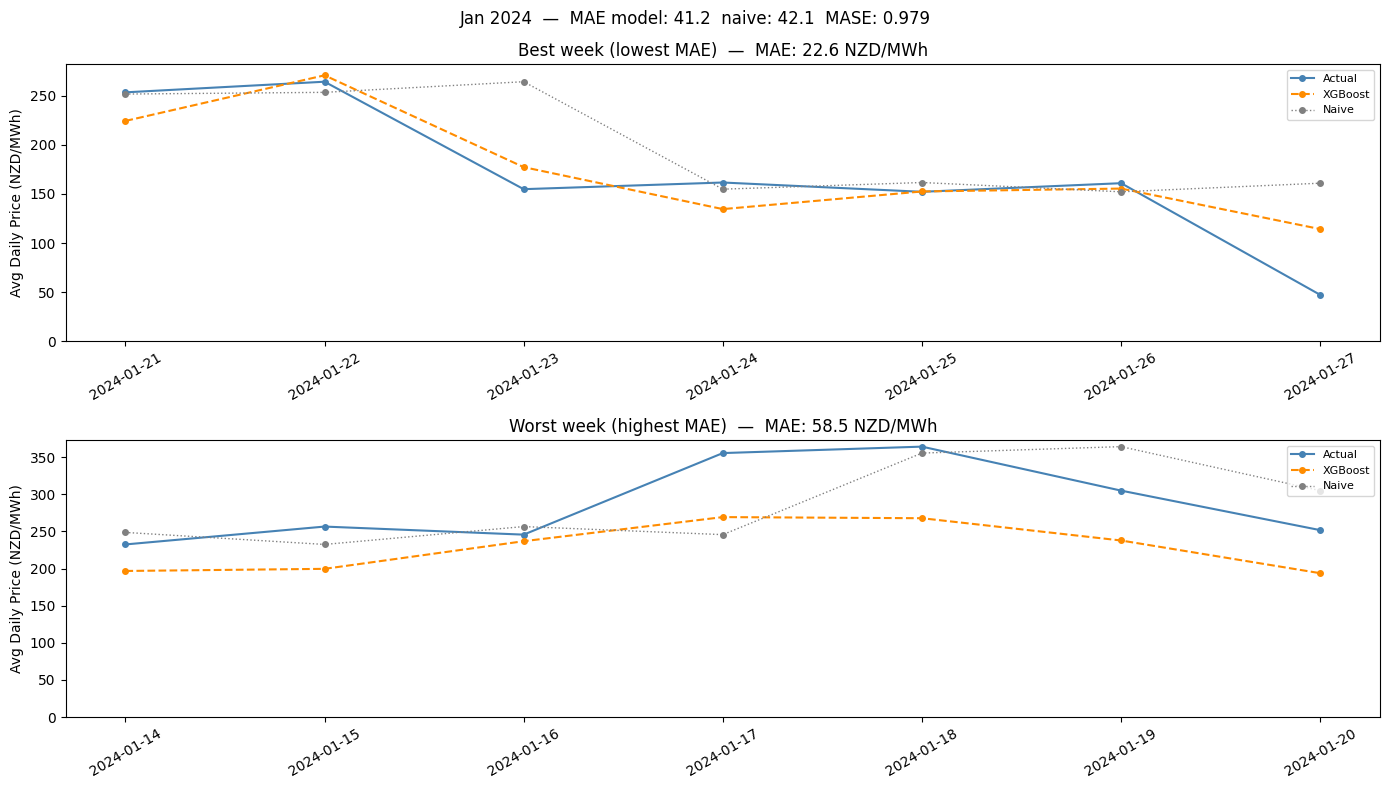

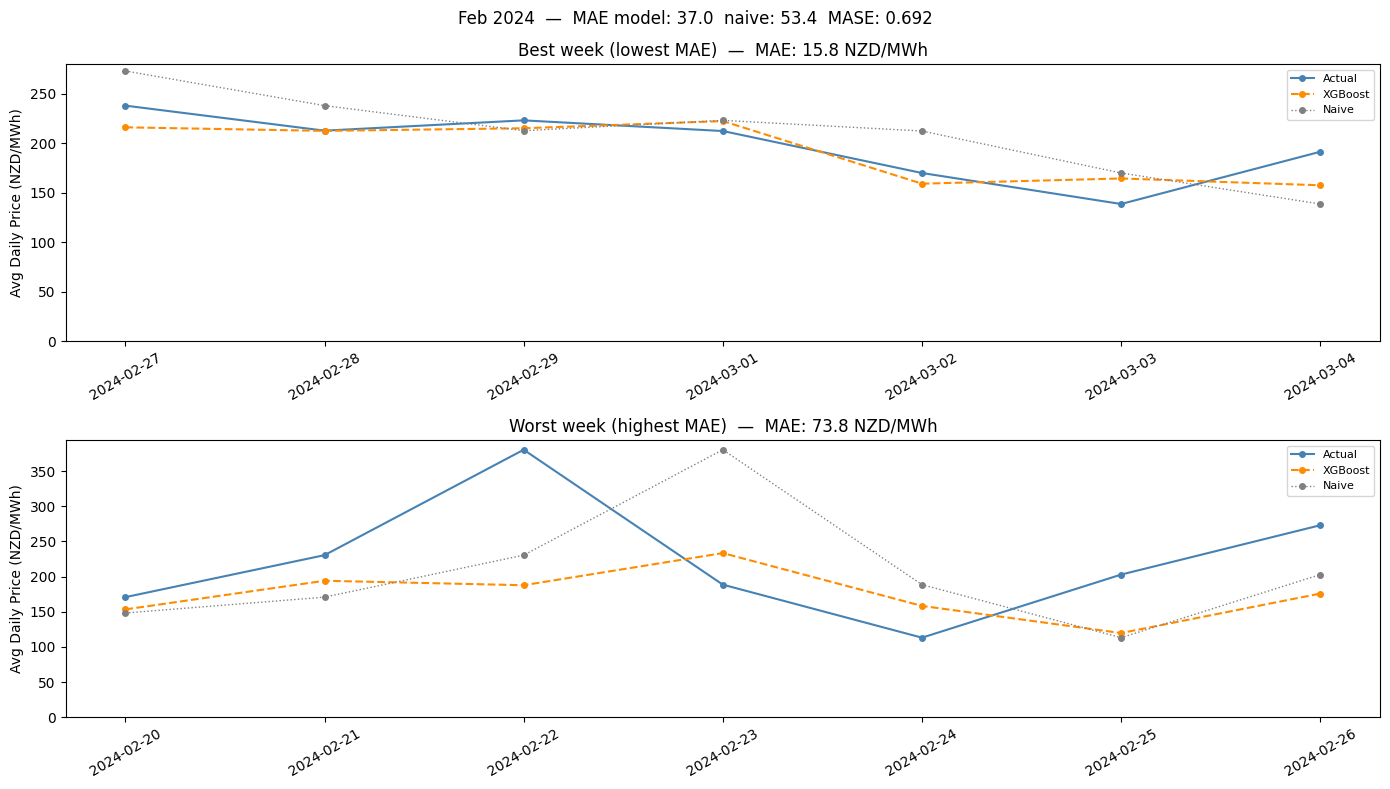

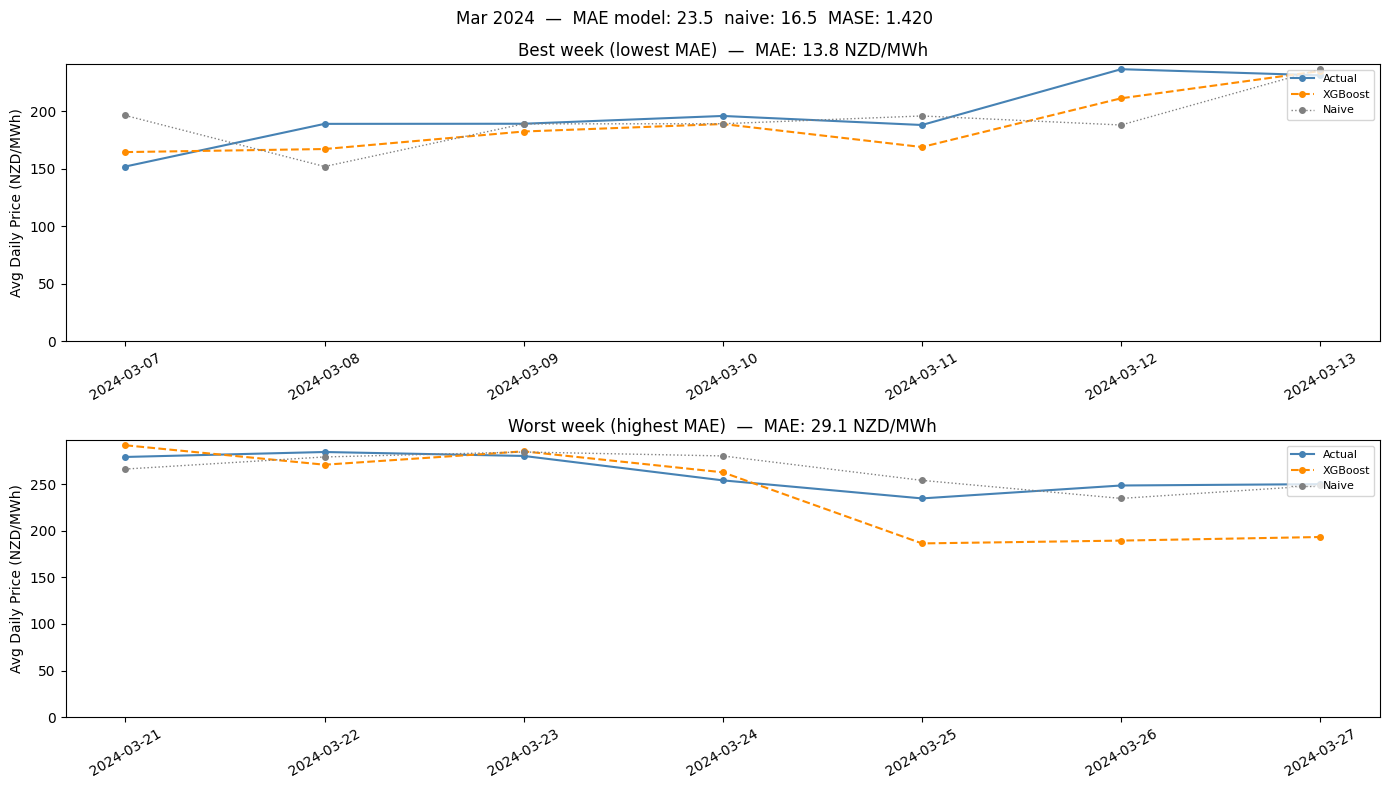

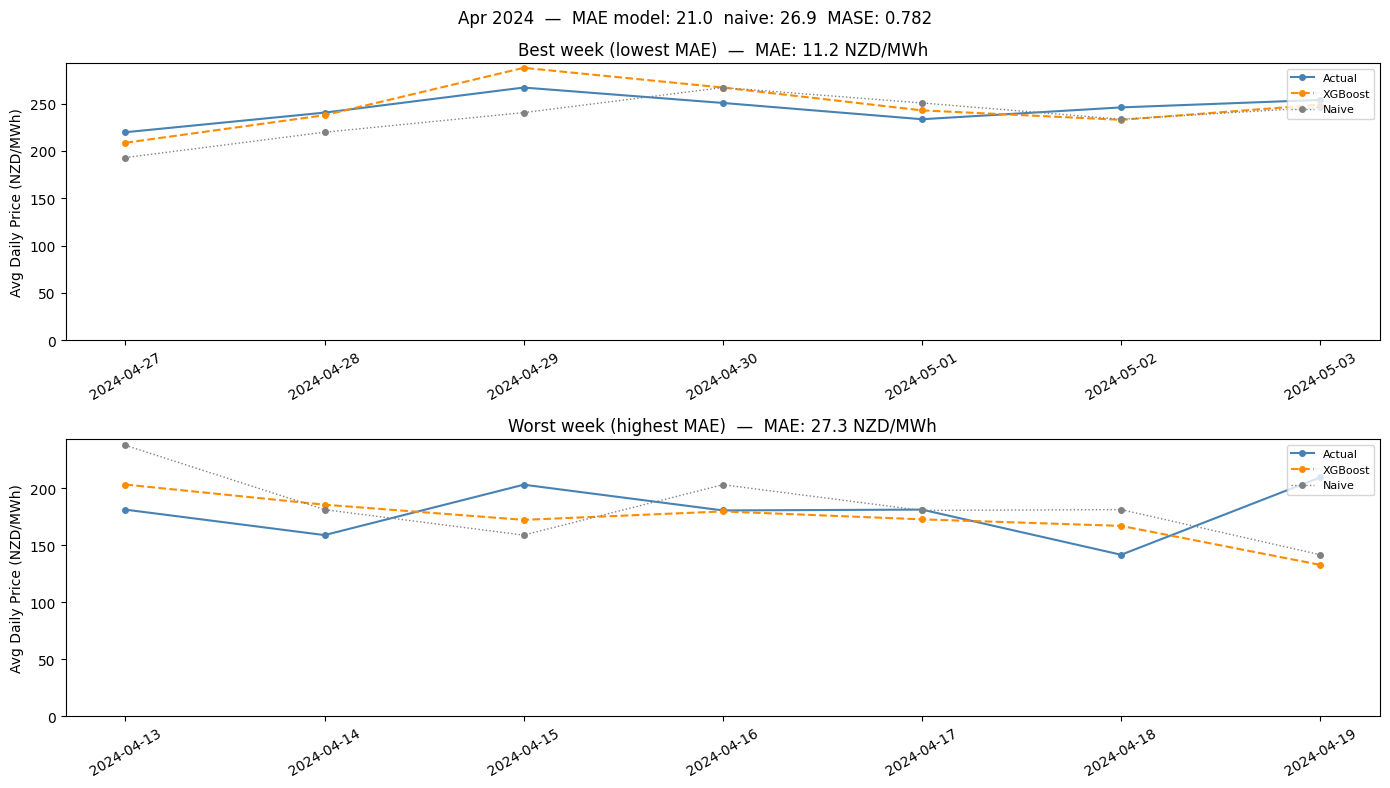

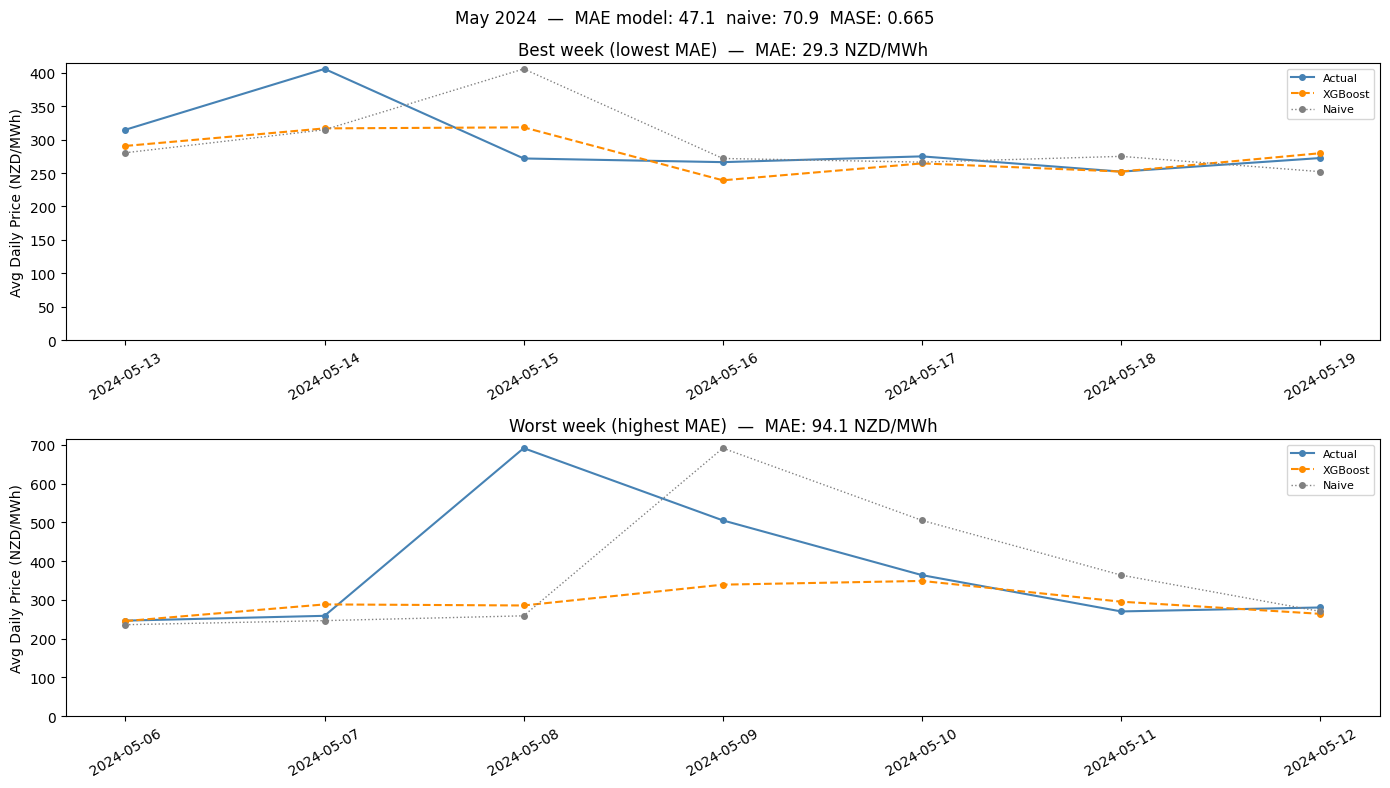

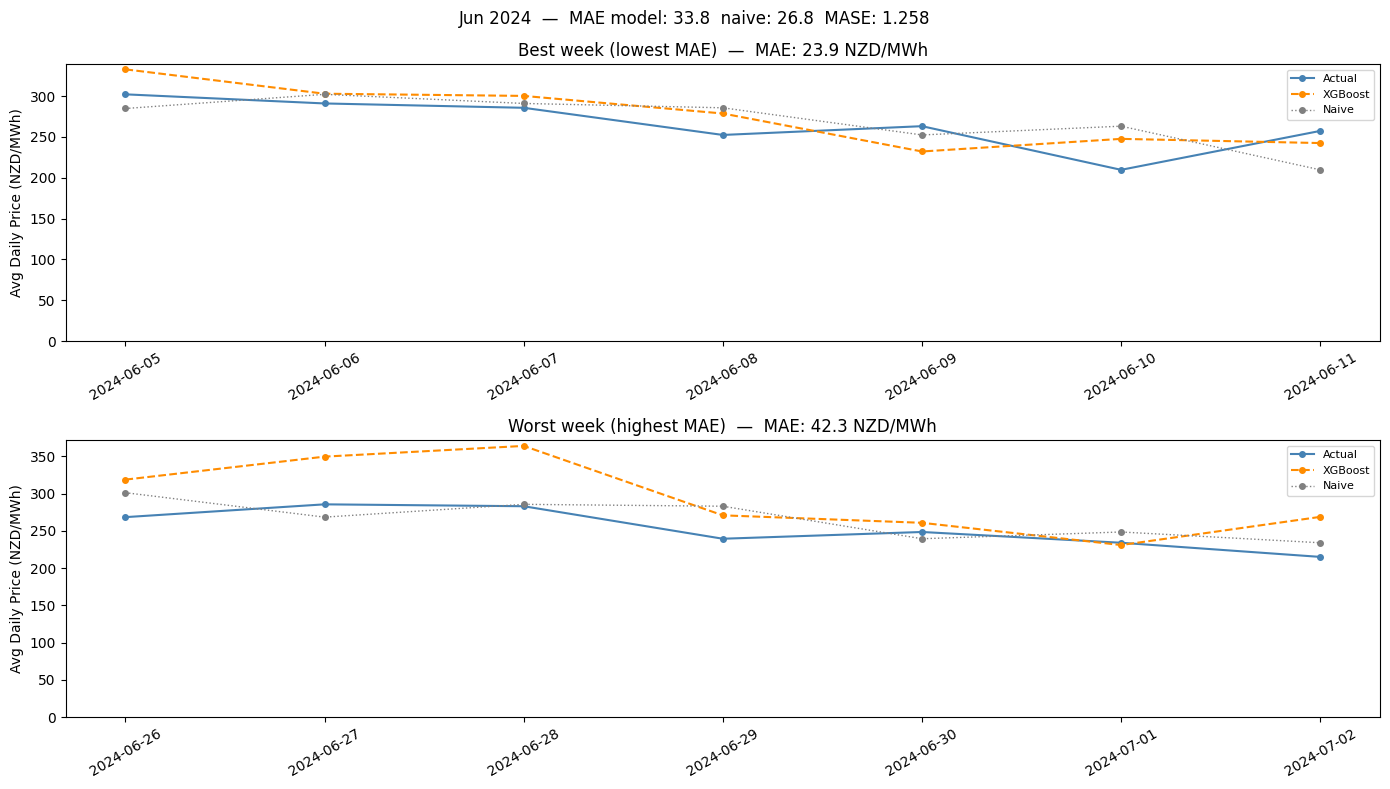

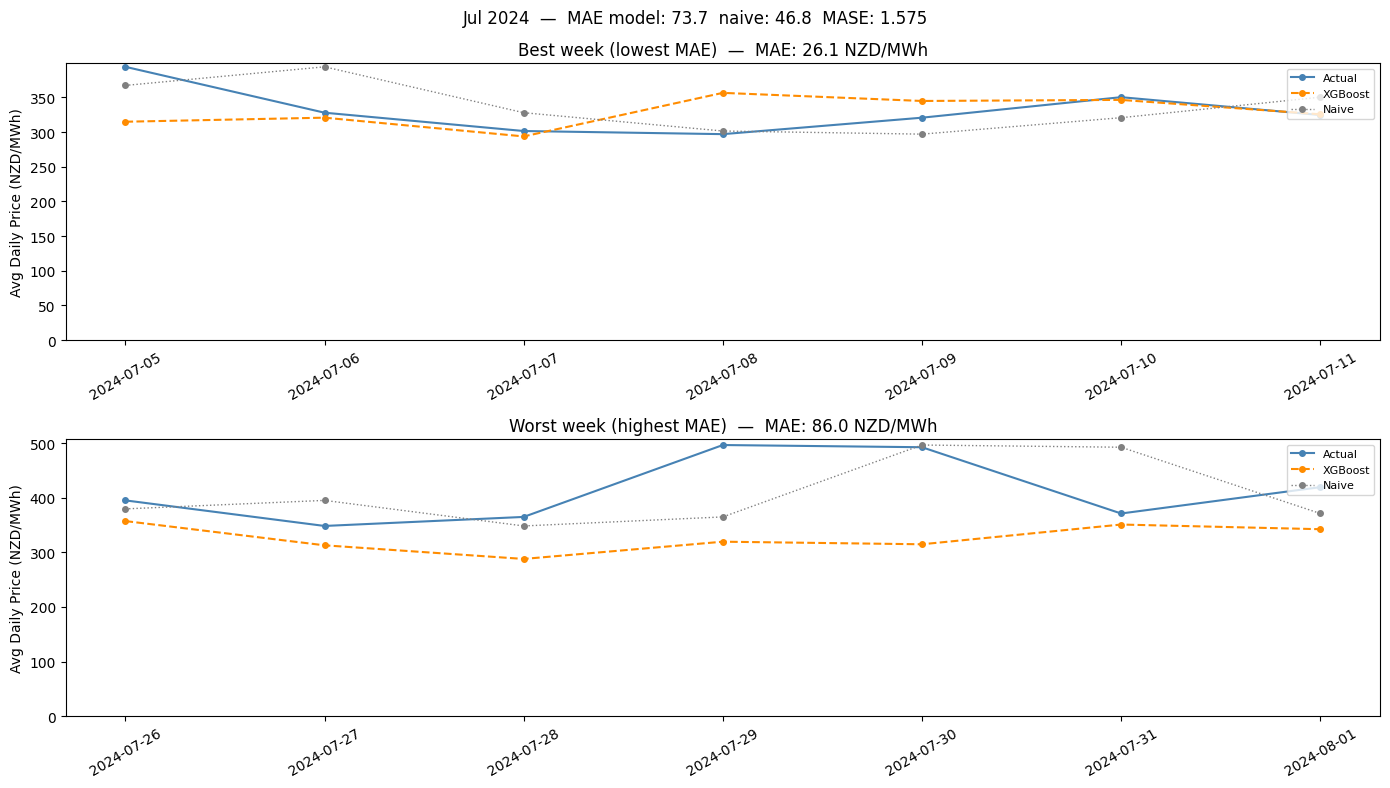

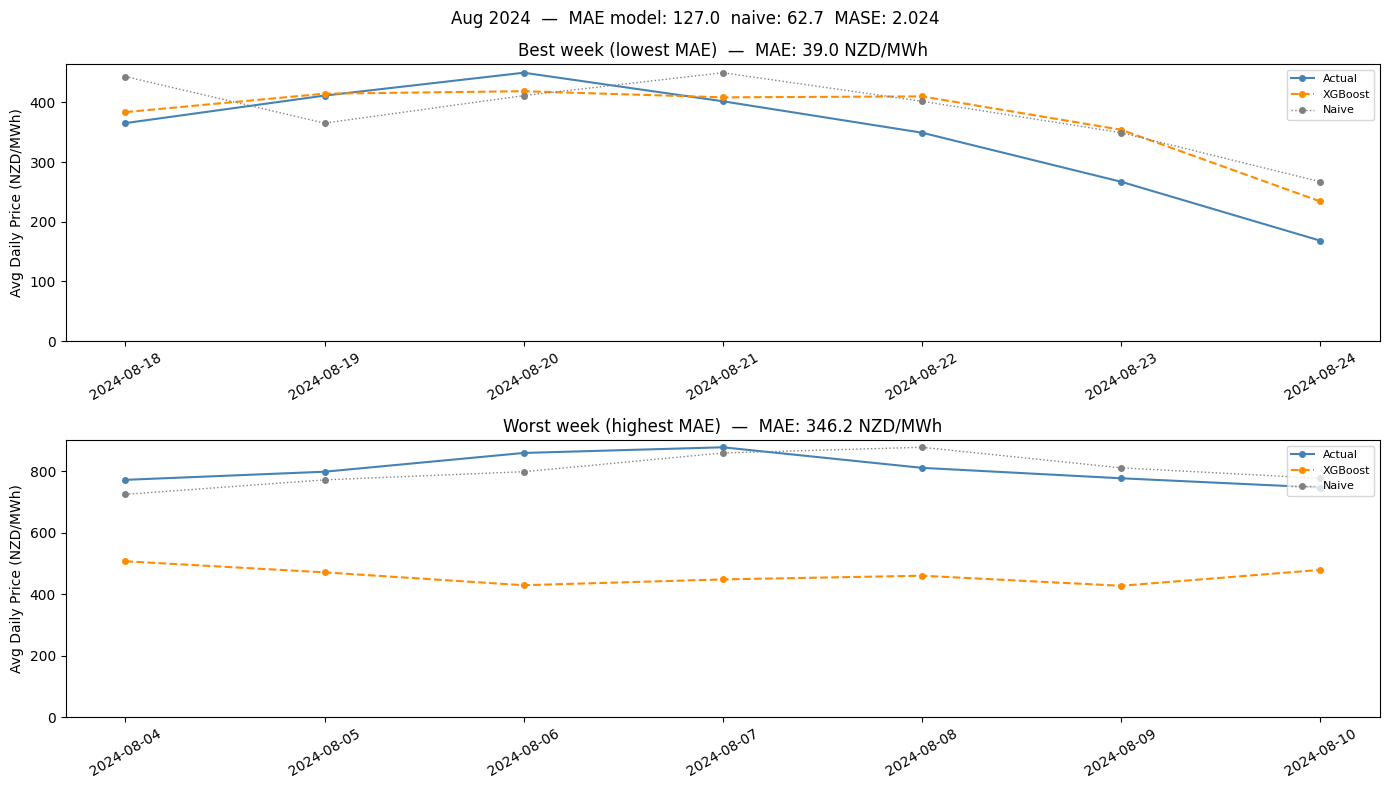

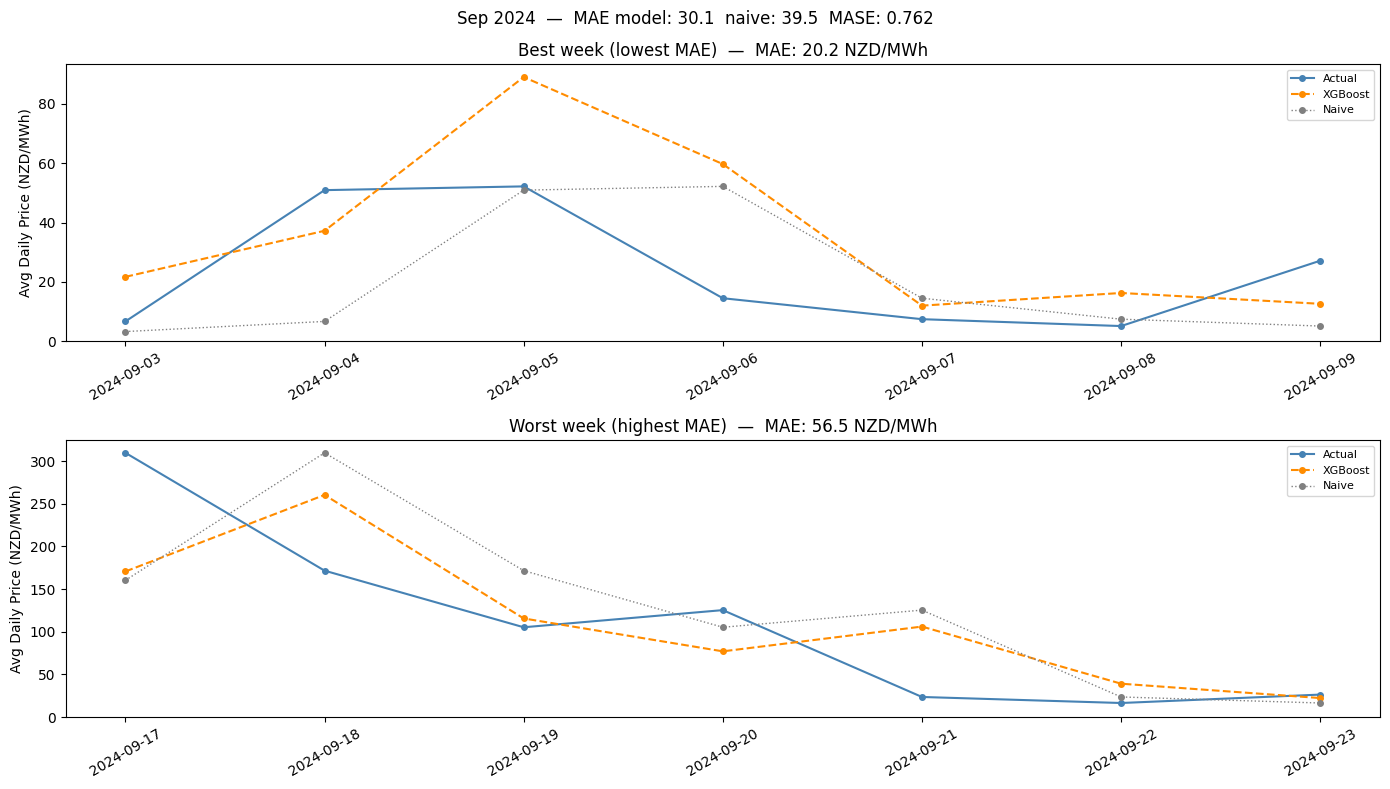

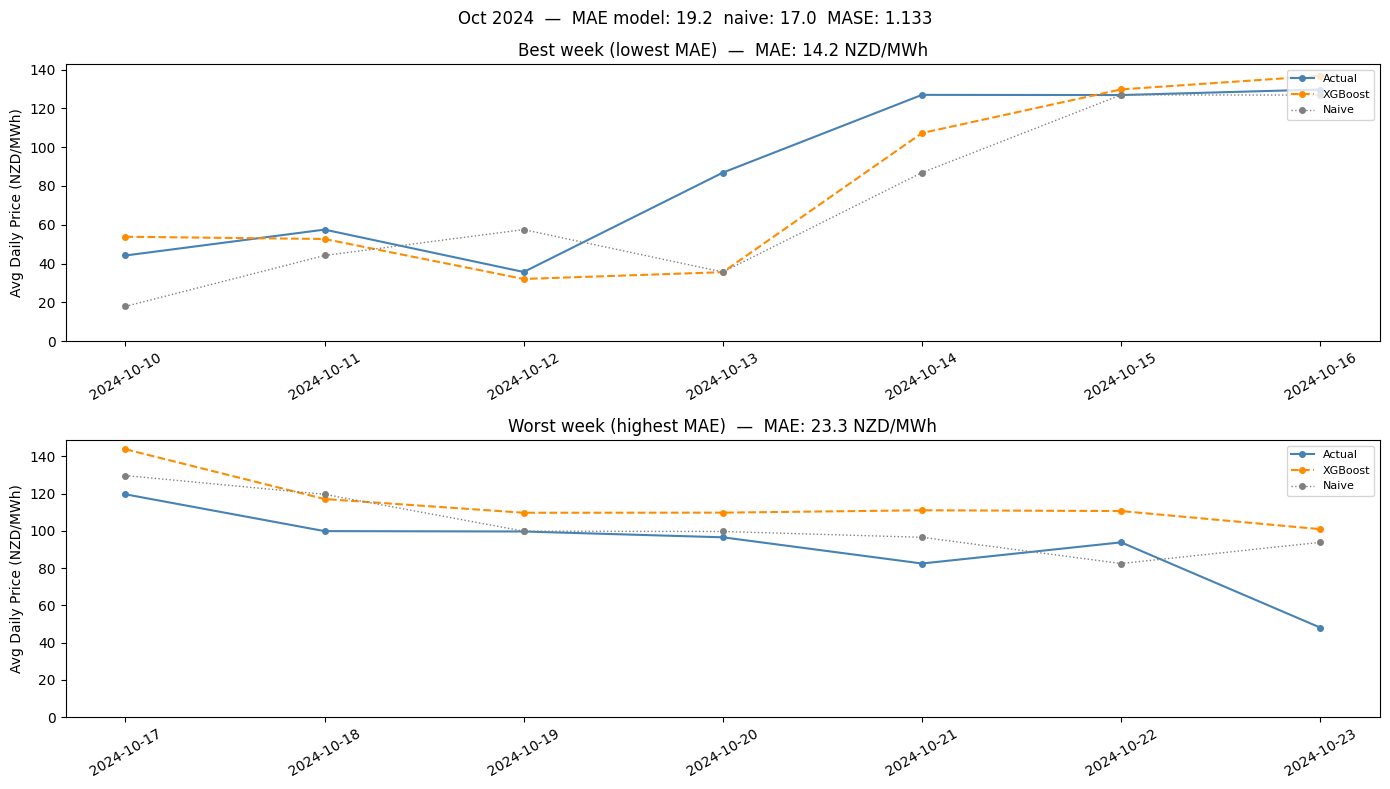

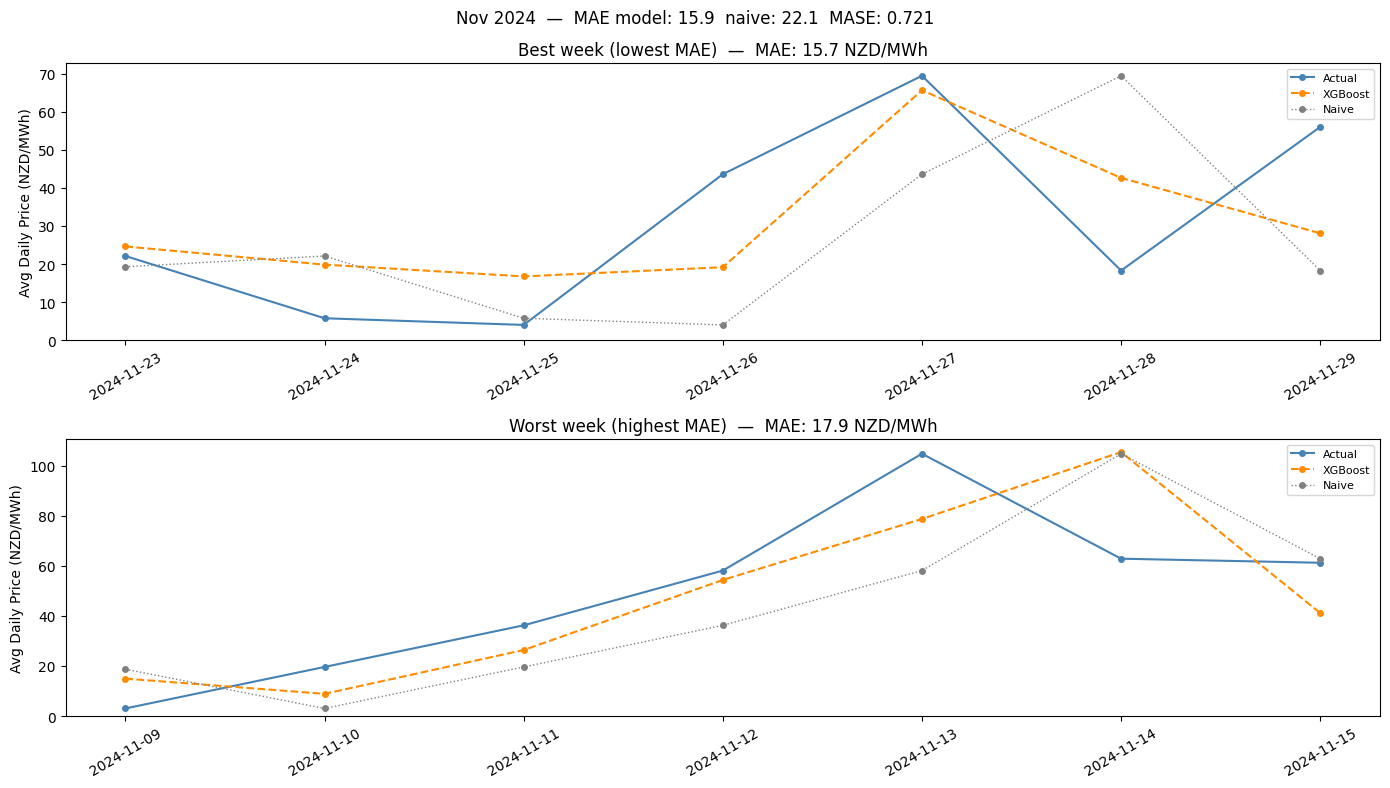

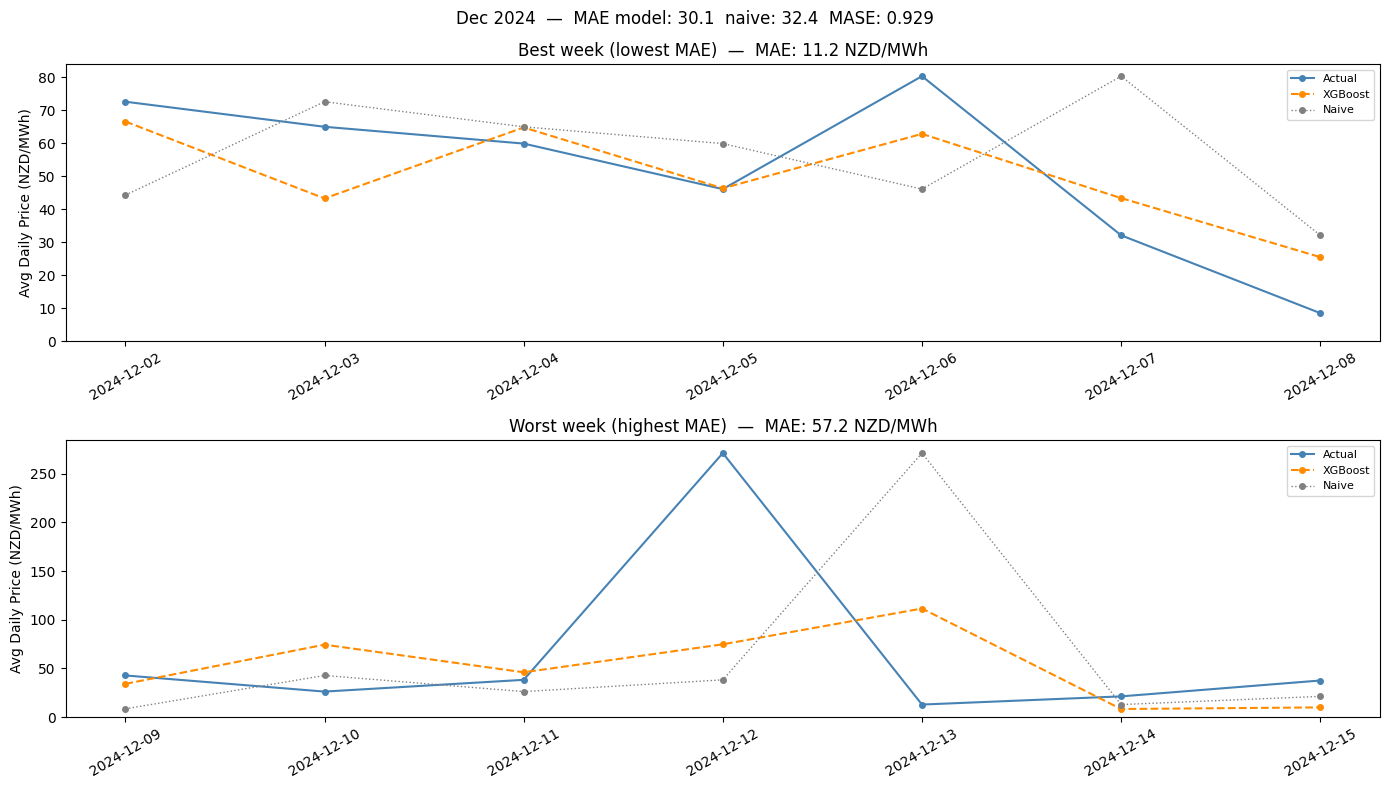

In [8]:
# ── Monthly Visualisation — Best & Worst Week per Fold ────────────────────────
# Each figure: 2 subplots — best week (lowest MAE) and worst week (highest MAE)
# Actual vs XGBoost vs Naive shown in each subplot

def find_best_worst_weeks(y_actual, y_model, week_size=7):
    n_weeks = len(y_actual) // week_size
    week_maes = []
    for w in range(n_weeks):
        s, e = w * week_size, (w + 1) * week_size
        week_maes.append((mean_absolute_error(y_actual[s:e], y_model[s:e]), s, e))
    return min(week_maes, key=lambda x: x[0]), max(week_maes, key=lambda x: x[0])


for r in fold_results:
    best, worst = find_best_worst_weeks(r["y_actual"], r["y_model"])

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(
        f"{r['month']}  —  MAE model: {r['mae_model']:.1f}  "
        f"naive: {r['mae_naive']:.1f}  MASE: {r['mase']:.3f}",
        fontsize=12
    )

    for ax, (mae, s, e), label in zip(
        axes,
        [best, worst],
        ["Best week (lowest MAE)", "Worst week (highest MAE)"]
    ):
        ts  = r["timestamps"][s:e]
        act = r["y_actual"][s:e]
        mod = r["y_model"][s:e]
        nav = r["y_naive"][s:e]

        ax.plot(ts, act, label="Actual",  color="steelblue",  linewidth=1.5, marker="o", markersize=4)
        ax.plot(ts, mod, label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--", marker="o", markersize=4)
        ax.plot(ts, nav, label="Naive",   color="gray",       linewidth=1.0, linestyle=":",  marker="o", markersize=4)
        ax.set_title(f"{label}  —  MAE: {mae:.1f} NZD/MWh")
        ax.set_ylabel("Avg Daily Price (NZD/MWh)")
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=8, loc="upper right")
        ax.tick_params(axis="x", labelrotation=30)

    plt.tight_layout()
    plt.show()

In [9]:
# ── Final Model — trained on 80% for feature importance & seasonal plots ──────

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

xgb_model = XGBRegressor(**MODEL_PARAMS)
xgb_model.fit(X_train, y_train)

y_pred = np.clip(xgb_model.predict(X_test), 0, None)

mae_f  = mean_absolute_error(y_test, y_pred)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred))
r2_f   = r2_score(y_test, y_pred)

print("Final model — 80% train / 20% test")
print(f"  Train: {df['datetime_utc12'].iloc[0].date()} → {df['datetime_utc12'].iloc[split_index-1].date()}")
print(f"  Test : {df['datetime_utc12'].iloc[split_index].date()} → {df['datetime_utc12'].iloc[-1].date()}")
print(f"  MAE  : {mae_f:.4f}")
print(f"  RMSE : {rmse_f:.4f}")
print(f"  R²   : {r2_f:.4f}")

Final model — 80% train / 20% test
  Train: 2020-01-01 → 2023-12-31
  Test : 2024-01-01 → 2024-12-31
  MAE  : 45.5202
  RMSE : 87.8407
  R²   : 0.6888


                       feature  importance
el_price_dol_MWh_ISL2201_lag1d        0.24
el_price_dol_MWh_KIK2201_lag1d        0.16
                 target_lag_1d        0.14
el_price_dol_MWh_HAY2201_lag1d        0.12
el_price_dol_MWh_SFD2201_lag1d        0.10
el_price_dol_MWh_WKM2201_lag1d        0.06
el_price_dol_MWh_RDF2201_lag1d        0.04
el_price_dol_MWh_INV2201_lag1d        0.03
el_price_dol_MWh_BEN2201_lag1d        0.02
               rolling_mean_7d        0.00
                     dayofweek        0.00
                       holiday        0.00
                     month_cos        0.00
              rolling_mean_30d        0.00
    SI_PKI__active_storage_mm³        0.00
                  Diesel_lag1d        0.00
                outage_UNKN_MW        0.00
                dunedin_temp_c        0.00
    SI_HWE__active_storage_mm³        0.00
          NI_TPO__lake_level_m        0.00


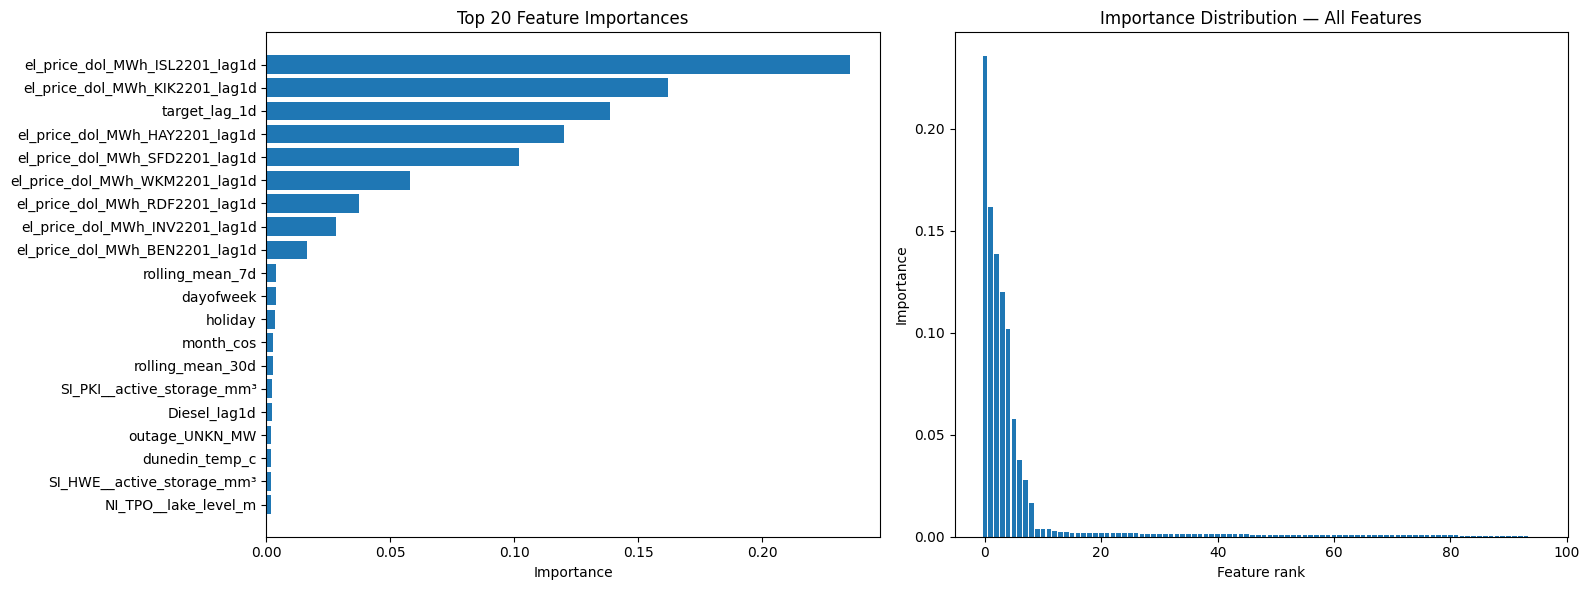

In [10]:
# ── Feature Importance ────────────────────────────────────────────────────────

importance_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = importance_df.head(20)
axes[0].barh(top20["feature"][::-1], top20["importance"][::-1])
axes[0].set_title("Top 20 Feature Importances")
axes[0].set_xlabel("Importance")

axes[1].bar(range(len(importance_df)), importance_df["importance"].values)
axes[1].set_title("Importance Distribution — All Features")
axes[1].set_xlabel("Feature rank")
axes[1].set_ylabel("Importance")

plt.tight_layout()
plt.show()

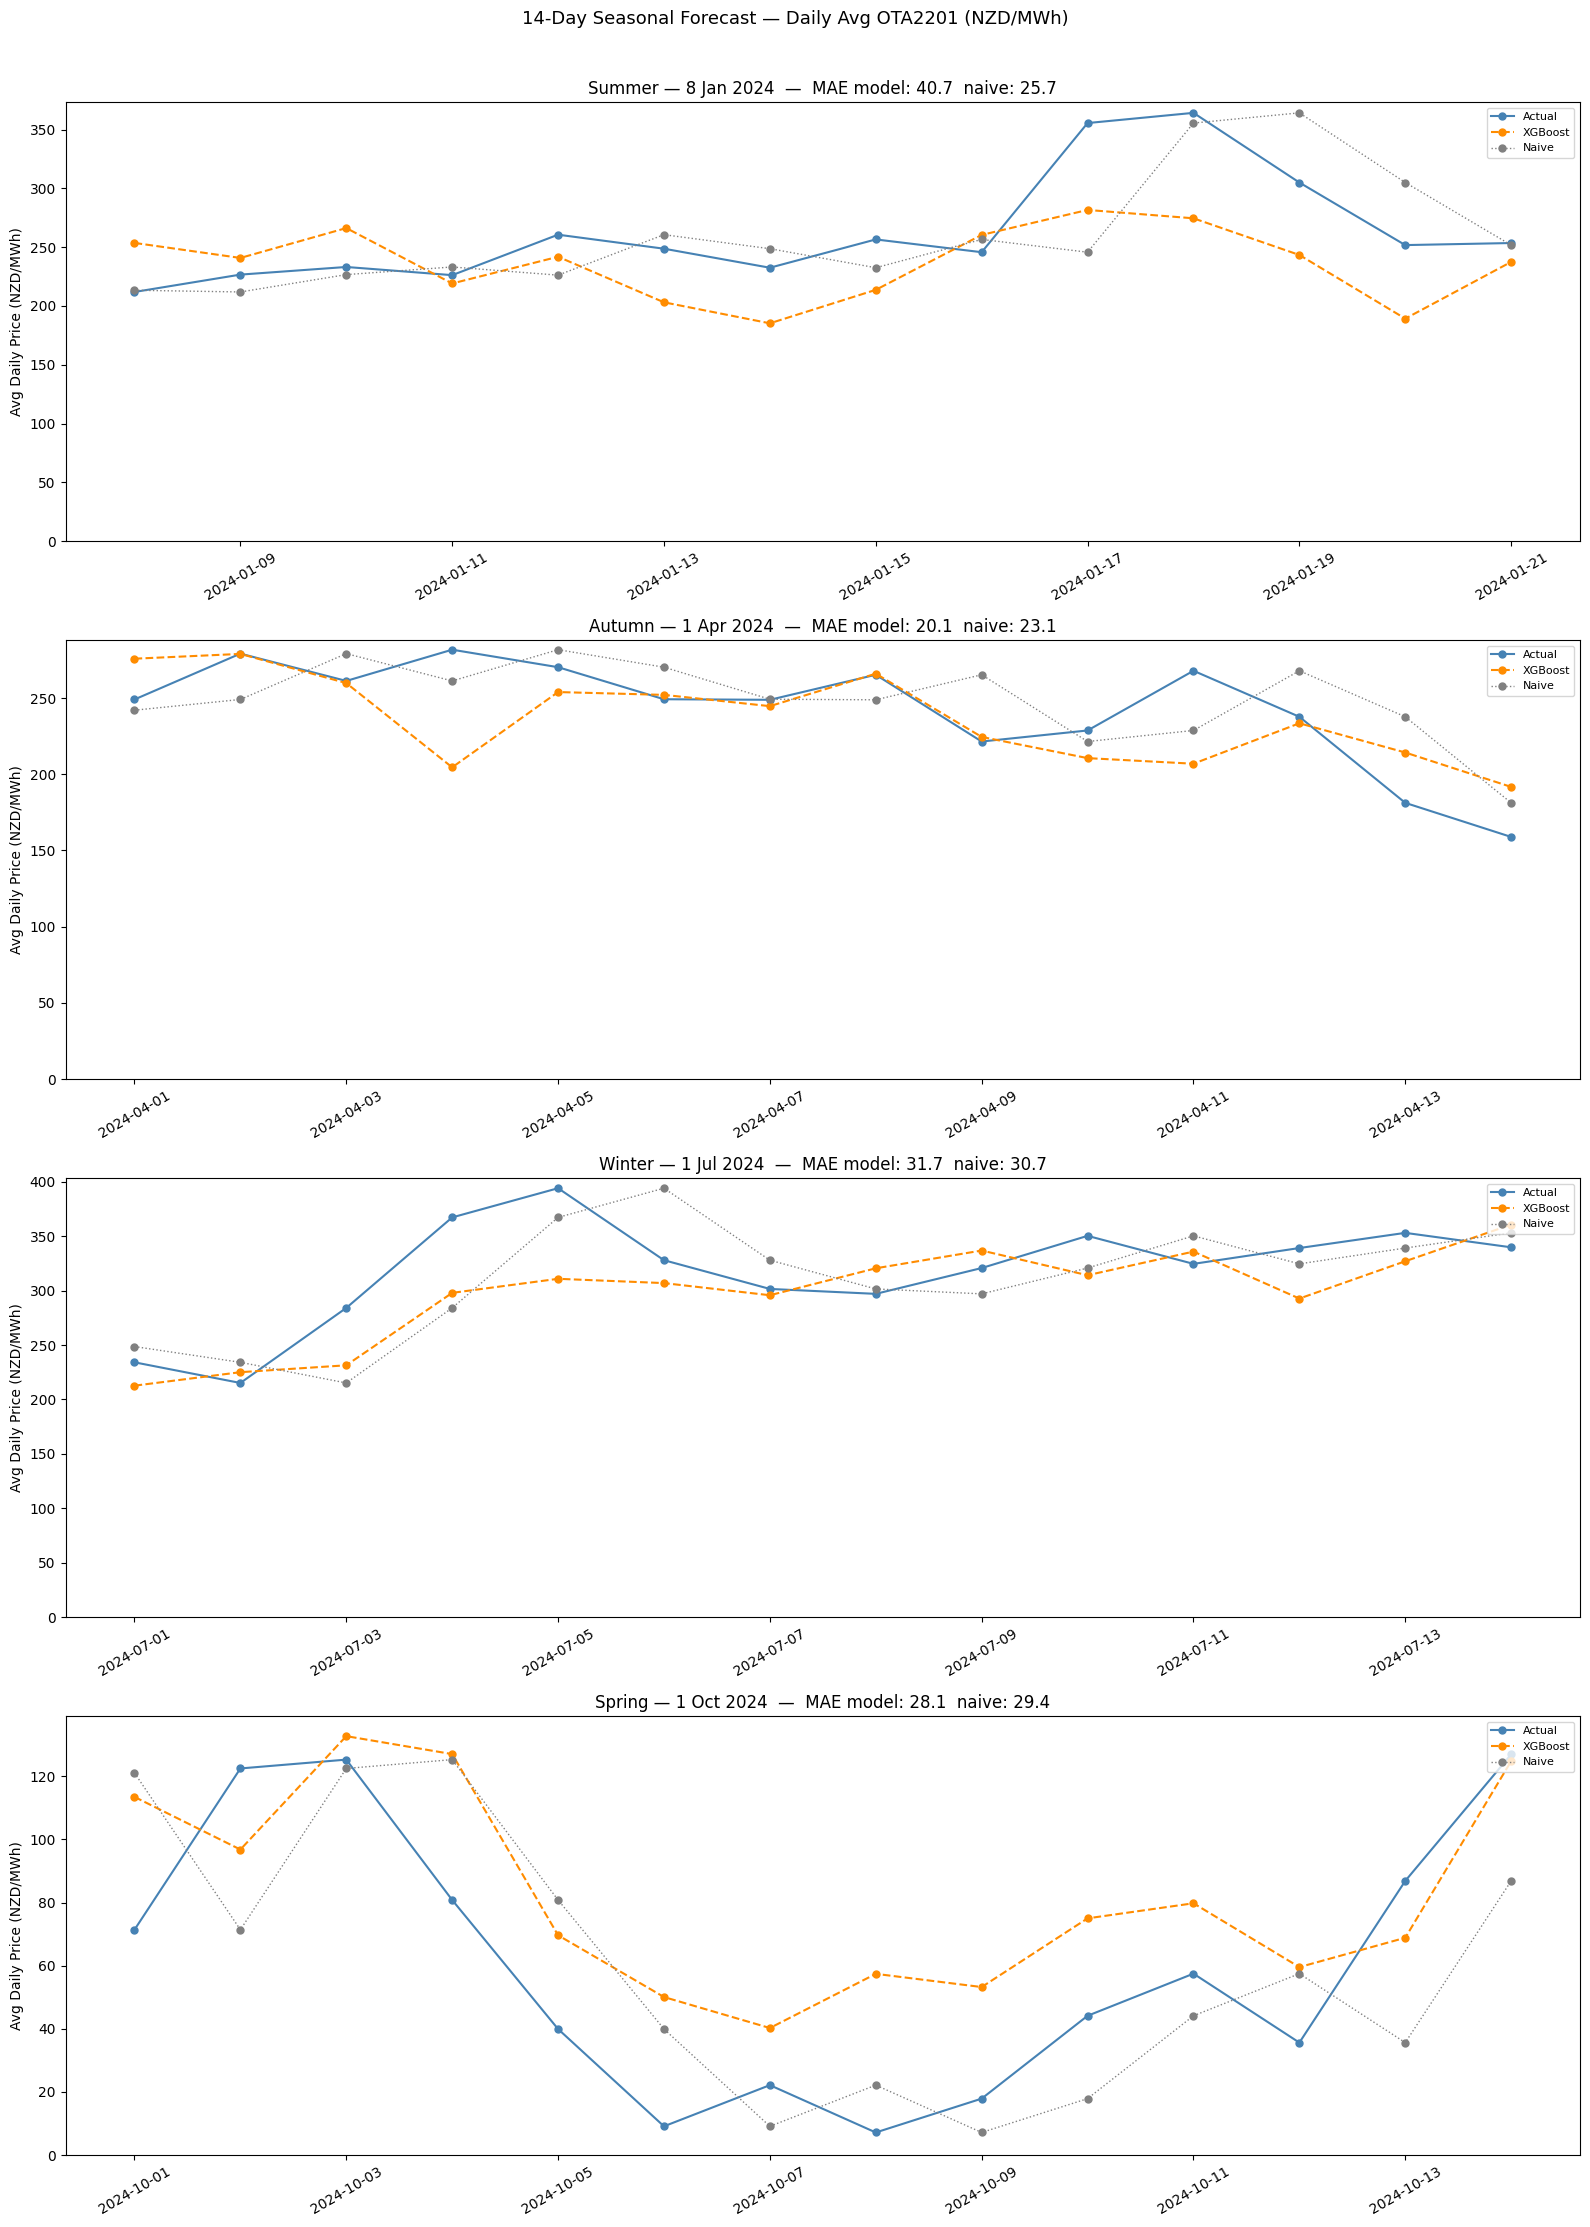

In [11]:
# ── Seasonal 14-Day Forecasts ─────────────────────────────────────────────────

def rolling_forecast(model, start_date, n_days=14):
    start_ts = pd.Timestamp(start_date)
    mask = (
        (df["datetime_utc12"] >= start_ts) &
        (df["datetime_utc12"] <  start_ts + pd.Timedelta(days=n_days))
    )
    d = df[mask].reset_index(drop=True)
    if len(d) < n_days:
        raise ValueError(f"Not enough data from {start_date}")
    preds = np.clip(model.predict(d[feature_cols].values), 0, None)
    naive = d["target_lag_1d"].values
    return preds, d[target_col].values, d["datetime_utc12"].values, naive


seasons = {
    "Summer — 8 Jan 2024":  "2024-01-08",
    "Autumn — 1 Apr 2024":  "2024-04-01",
    "Winter — 1 Jul 2024":  "2024-07-01",
    "Spring — 1 Oct 2024":  "2024-10-01",
}

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("14-Day Seasonal Forecast — Daily Avg OTA2201 (NZD/MWh)", fontsize=13, y=1.01)

for ax, (label, start) in zip(axes, seasons.items()):
    preds, actuals, ts, naive = rolling_forecast(xgb_model, start)
    mae_m = mean_absolute_error(actuals, preds)
    mae_n = mean_absolute_error(actuals, naive)

    ax.plot(ts, actuals, label="Actual",  color="steelblue",  linewidth=1.5, marker="o", markersize=5)
    ax.plot(ts, preds,   label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--", marker="o", markersize=5)
    ax.plot(ts, naive,   label="Naive",   color="gray",       linewidth=1.0, linestyle=":",  marker="o", markersize=5)
    ax.set_title(f"{label}  —  MAE model: {mae_m:.1f}  naive: {mae_n:.1f}")
    ax.set_ylabel("Avg Daily Price (NZD/MWh)")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis="x", labelrotation=30)

plt.tight_layout()
plt.show()